# Single Backtest Viewer

Auto-discovers the latest single backtest run from either:
- `eval_results/backtest/<run_dir>`
- `eval_results/backtest/ab_pairs/<pair_dir>/run_a|run_b`

Focus:
- single-run summary statistics
- equity curve vs benchmark
- portfolio weights and concentration
- order flow and trading cost totals


In [17]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

def _resolve_backtest_root() -> Path:
    for c in (Path('eval_results/backtest'), Path('../eval_results/backtest')):
        if c.exists():
            return c
    return Path('eval_results/backtest')

def _is_run_dir(path: Path) -> bool:
    return path.is_dir() and (path / 'summary.json').exists() and (path / 'equity_curve.csv').exists()

def _collect_runs(root: Path) -> list[dict]:
    runs = []
    if root.exists():
        for p in root.iterdir():
            if p.name == 'ab_pairs':
                continue
            if _is_run_dir(p):
                runs.append({'run_dir': p, 'source': 'single', 'pair': None})

    pair_root = root / 'ab_pairs'
    if pair_root.exists():
        for pair in pair_root.iterdir():
            if not pair.is_dir():
                continue
            for child in ('run_a', 'run_b'):
                rp = pair / child
                if _is_run_dir(rp):
                    runs.append({'run_dir': rp, 'source': f'ab_{child}', 'pair': pair.name})

    for r in runs:
        s = r['run_dir'] / 'summary.json'
        e = r['run_dir'] / 'equity_curve.csv'
        r['mtime'] = max(s.stat().st_mtime, e.stat().st_mtime)

    runs.sort(key=lambda x: x['mtime'], reverse=True)
    return runs

BACKTEST_ROOT = _resolve_backtest_root()
RUNS = _collect_runs(BACKTEST_ROOT)
assert RUNS, f'No valid backtest runs found under {BACKTEST_ROOT.resolve()}'

top = pd.DataFrame([
    {
        'rank': i + 1,
        'run_dir': str(r['run_dir']),
        'source': r['source'],
        'pair': r['pair'],
        'modified_at': pd.to_datetime(r['mtime'], unit='s'),
    }
    for i, r in enumerate(RUNS[:12])
])
display(top)


,rank,run_dir,source,pair,modified_at
0,1,../eval_results/backtest/ab_pairs/20260301T221...,ab_run_b,20260301T221628Z_sec_top2_te012_with_vs_withou...,2026-03-01 22:17:01.348979712
1,2,../eval_results/backtest/ab_pairs/20260301T221...,ab_run_a,20260301T221628Z_sec_top2_te012_with_vs_withou...,2026-03-01 22:16:48.250201702
2,3,../eval_results/backtest/ab_pairs/20260301T221...,ab_run_b,20260301T221205Z_sec_top2_te012_with_vs_withou...,2026-03-01 22:12:37.813877344
3,4,../eval_results/backtest/ab_pairs/20260301T221...,ab_run_a,20260301T221205Z_sec_top2_te012_with_vs_withou...,2026-03-01 22:12:25.390260935
4,5,../eval_results/backtest/ab_pairs/20260301T214...,ab_run_b,20260301T214358Z_sec_top2_te012_with_vs_withou...,2026-03-01 21:44:31.567110062
5,6,../eval_results/backtest/ab_pairs/20260301T214...,ab_run_a,20260301T214358Z_sec_top2_te012_with_vs_withou...,2026-03-01 21:44:18.843675137
6,7,../eval_results/backtest/ab_pairs/20260301T214...,ab_run_b,20260301T214323Z_sec_top2_te010_with_vs_withou...,2026-03-01 21:43:58.064108848
7,8,../eval_results/backtest/ab_pairs/20260301T214...,ab_run_a,20260301T214323Z_sec_top2_te010_with_vs_withou...,2026-03-01 21:43:45.000195026
8,9,../eval_results/backtest/ab_pairs/20260301T214...,ab_run_b,20260301T214249Z_sec_top2_te008_with_vs_withou...,2026-03-01 21:43:23.058777571
9,10,../eval_results/backtest/ab_pairs/20260301T214...,ab_run_a,20260301T214249Z_sec_top2_te008_with_vs_withou...,2026-03-01 21:43:09.455827236


In [18]:
# Defaults to latest discovered run. Uncomment to pin.
RUN_DIR = Path(RUNS[0]['run_dir'])
# RUN_DIR = Path('eval_results/backtest/ab_pairs/<pair_dir>/run_b')

summary = json.loads((RUN_DIR / 'summary.json').read_text())
eq = pd.read_csv(RUN_DIR / 'equity_curve.csv')
eq['trade_date'] = pd.to_datetime(eq['trade_date'])
weights_path = RUN_DIR / 'weights_history.csv'
orders_path = RUN_DIR / 'orders_history.csv'
weights_history = pd.read_csv(weights_path) if weights_path.exists() else None
orders_history = pd.read_csv(orders_path) if orders_path.exists() else None
if weights_history is not None and 'trade_date' in weights_history.columns:
    weights_history['trade_date'] = pd.to_datetime(weights_history['trade_date'])
if orders_history is not None and 'trade_date' in orders_history.columns:
    orders_history['trade_date'] = pd.to_datetime(orders_history['trade_date'])

print('Selected run:', RUN_DIR)
print('Date window:', summary.get('start_date'), '->', summary.get('end_date'))
print('Has weights_history:', weights_history is not None)
print('Has orders_history:', orders_history is not None)


Selected run: ../eval_results/backtest/ab_pairs/20260301T221628Z_sec_top2_te012_with_vs_without_sector_active_band_feasible_rerun2/run_b
Date window: 2021-05-21 -> 2026-02-28
Has weights_history: True
Has orders_history: True


In [19]:
summary_keys = [
    'total_return', 'cagr', 'annualized_volatility', 'sharpe', 'max_drawdown',
    'tracking_error', 'realized_active_information_ratio',
    'average_ic', 'average_breadth_proxy', 'average_transfer_coefficient',
    'average_transfer_coefficient_corrected', 'average_transfer_coefficient_legacy_proxy',
    'implied_information_ratio',
    'average_raw_turnover', 'average_executed_turnover', 'average_turnover_constraint_drag',
    'rebalance_points', 'final_nav', 'initial_capital'
]
summary_view = pd.DataFrame([
    {'metric': k, 'value': summary.get(k)} for k in summary_keys if k in summary
])
if {'average_transfer_coefficient_corrected', 'average_transfer_coefficient_legacy_proxy'} <= set(summary_view['metric']):
    corrected = float(summary.get('average_transfer_coefficient_corrected'))
    legacy = float(summary.get('average_transfer_coefficient_legacy_proxy'))
    summary_view = pd.concat([
        summary_view,
        pd.DataFrame([
            {'metric': 'transfer_coefficient_gap_legacy_minus_corrected', 'value': legacy - corrected},
            {'metric': 'transfer_coefficient_ratio_corrected_vs_legacy', 'value': corrected / legacy if legacy else float('nan')},
        ])
    ], ignore_index=True)
summary_view


,metric,value
0,total_return,1.162983e+00
1,cagr,2.127277e-01
2,annualized_volatility,2.024433e-01
3,sharpe,1.139572e+00
4,max_drawdown,-2.245754e-01
5,tracking_error,8.905602e-02
6,realized_active_information_ratio,1.001000e+00
7,average_ic,1.823838e-02
8,average_breadth_proxy,2.804683e+01
9,average_transfer_coefficient_proxy,9.091786e-01


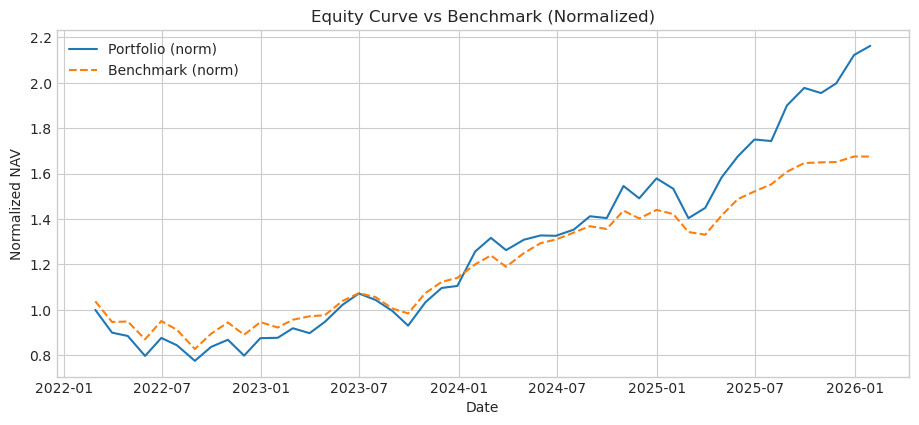

In [20]:
eq_plot = eq.copy()
eq_plot['portfolio_nav_norm'] = eq_plot['nav'] / float(eq_plot['nav'].iloc[0])
eq_plot['benchmark_nav_norm'] = (1.0 + pd.to_numeric(eq_plot['benchmark_return'], errors='coerce').fillna(0.0)).cumprod()

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(eq_plot['trade_date'], eq_plot['portfolio_nav_norm'], label='Portfolio (norm)')
ax.plot(eq_plot['trade_date'], eq_plot['benchmark_nav_norm'], label='Benchmark (norm)', linestyle='--')
ax.set_title('Equity Curve vs Benchmark (Normalized)')
ax.set_xlabel('Date')
ax.set_ylabel('Normalized NAV')
ax.legend()
plt.show()


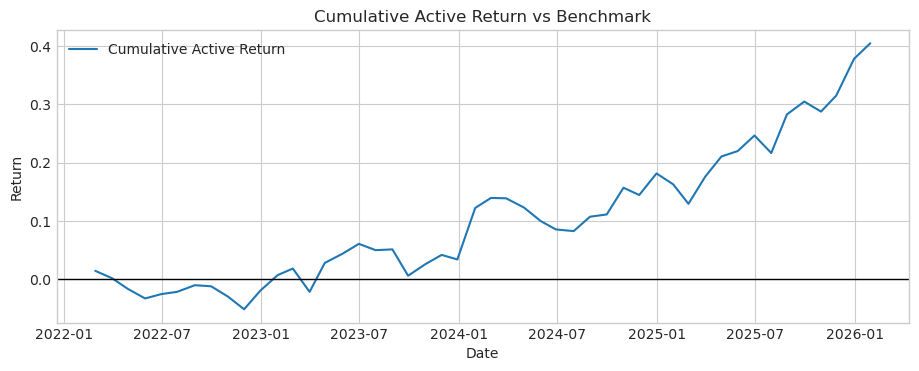

In [21]:
eq_plot = eq.copy()
eq_plot['active_return'] = pd.to_numeric(eq_plot['portfolio_return'], errors='coerce').fillna(0.0) - pd.to_numeric(eq_plot['benchmark_return'], errors='coerce').fillna(0.0)
eq_plot['cum_active_return'] = (1.0 + eq_plot['active_return']).cumprod() - 1.0

fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(eq_plot['trade_date'], eq_plot['cum_active_return'], label='Cumulative Active Return')
ax.axhline(0.0, color='black', linewidth=1)
ax.set_title('Cumulative Active Return vs Benchmark')
ax.set_xlabel('Date')
ax.set_ylabel('Return')
ax.legend()
plt.show()


In [22]:
cost_series = pd.to_numeric(eq['cost'], errors='coerce').fillna(0.0) if 'cost' in eq.columns else pd.Series(0.0, index=eq.index)
turnover_series = pd.to_numeric(eq['turnover'], errors='coerce').fillna(0.0) if 'turnover' in eq.columns else pd.Series(0.0, index=eq.index)
raw_turnover_series = pd.to_numeric(eq['raw_turnover'], errors='coerce').fillna(0.0) if 'raw_turnover' in eq.columns else pd.Series(0.0, index=eq.index)

execution_summary = pd.DataFrame([
    {'metric': 'rebalance_rows', 'value': int(len(eq))},
    {'metric': 'total_cost', 'value': float(cost_series.sum())},
    {'metric': 'avg_cost_per_rebalance', 'value': float(cost_series.mean()) if len(cost_series) else 0.0},
    {'metric': 'total_executed_turnover', 'value': float(turnover_series.sum())},
    {'metric': 'total_raw_turnover', 'value': float(raw_turnover_series.sum())},
])
display(execution_summary)

if orders_history is not None and len(orders_history) > 0:
    est_cost_col = pd.to_numeric(orders_history.get('estimated_cost', 0.0), errors='coerce').fillna(0.0)
    notional_col = pd.to_numeric(orders_history.get('notional', 0.0), errors='coerce').fillna(0.0)
    buys = int((orders_history.get('action', '') == 'BUY').sum()) if 'action' in orders_history.columns else 0
    sells = int((orders_history.get('action', '') == 'SELL').sum()) if 'action' in orders_history.columns else 0
    order_summary = pd.DataFrame([
        {'metric': 'orders_count', 'value': int(len(orders_history))},
        {'metric': 'buy_orders', 'value': buys},
        {'metric': 'sell_orders', 'value': sells},
        {'metric': 'gross_notional_traded', 'value': float(notional_col.abs().sum())},
        {'metric': 'net_notional_traded', 'value': float(notional_col.sum())},
        {'metric': 'orders_estimated_cost_total', 'value': float(est_cost_col.sum())},
    ])
    display(order_summary)
else:
    print('orders_history.csv not found for selected run.')


,metric,value
0,rebalance_rows,48.000000
1,total_cost,16801.171950
2,avg_cost_per_rebalance,350.024416
3,total_executed_turnover,25.844758
4,total_raw_turnover,46.467488


,metric,value
0,orders_count,5.263000e+03
1,buy_orders,1.590000e+03
2,sell_orders,3.673000e+03
3,gross_notional_traded,3.360234e+07
4,net_notional_traded,4.271581e-03
5,orders_estimated_cost_total,1.680117e+04


,metric,value
0,latest_trade_date,2026-01-30 00:00:00
1,positions_count,99
2,sum_weights,1.0
3,top_10_weight,0.558796
4,top_20_weight,0.921558
5,hhi,0.047099
6,effective_n,21.231662


,trade_date,symbol,weight
0,2026-01-30,NVDA,0.079907
1,2026-01-30,GOOGL,0.073835
2,2026-01-30,TSLA,0.071721
3,2026-01-30,MU,0.065207
4,2026-01-30,LLY,0.051378
5,2026-01-30,WDC,0.044366
6,2026-01-30,KO,0.043816
7,2026-01-30,NEM,0.043082
8,2026-01-30,WBD,0.042922
9,2026-01-30,C,0.042560


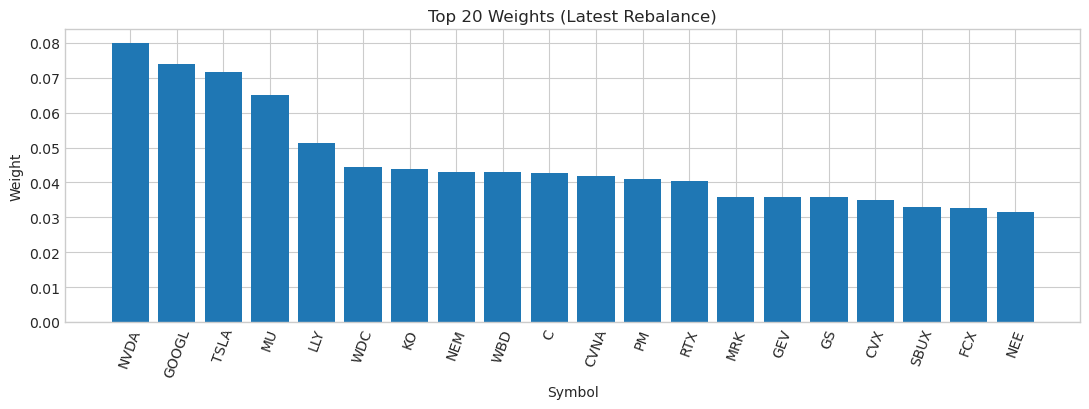

In [23]:
if weights_history is not None and len(weights_history) > 0:
    weight_cols = [c for c in weights_history.columns if c != 'trade_date']
    w_long = weights_history.melt(id_vars='trade_date', value_vars=weight_cols, var_name='symbol', value_name='weight')
    w_long['weight'] = pd.to_numeric(w_long['weight'], errors='coerce').fillna(0.0)
    w_long = w_long[w_long['weight'] > 0.0]
    latest_date = w_long['trade_date'].max()
    latest_w = w_long[w_long['trade_date'] == latest_date].sort_values('weight', ascending=False)
    latest_total = float(latest_w['weight'].sum())
    hhi = float((latest_w['weight'] ** 2).sum())
    effective_n = (1.0 / hhi) if hhi > 0 else 0.0
    concentration = pd.DataFrame([
        {'metric': 'latest_trade_date', 'value': latest_date},
        {'metric': 'positions_count', 'value': int(len(latest_w))},
        {'metric': 'sum_weights', 'value': latest_total},
        {'metric': 'top_10_weight', 'value': float(latest_w['weight'].head(10).sum())},
        {'metric': 'top_20_weight', 'value': float(latest_w['weight'].head(20).sum())},
        {'metric': 'hhi', 'value': hhi},
        {'metric': 'effective_n', 'value': effective_n},
    ])
    display(concentration)
    display(latest_w.head(25).reset_index(drop=True))

    fig, ax = plt.subplots(figsize=(11, 4.2))
    topn = latest_w.head(20)
    ax.bar(topn['symbol'], topn['weight'])
    ax.set_title('Top 20 Weights (Latest Rebalance)')
    ax.set_xlabel('Symbol')
    ax.set_ylabel('Weight')
    ax.tick_params(axis='x', rotation=70)
    plt.tight_layout()
    plt.show()
else:
    print('weights_history.csv not found for selected run.')


,trade_date,orders_count,gross_notional,net_notional,estimated_cost
28,2024-06-28,103,6.992689e+05,-2.438619e-10,349.634460
29,2024-07-31,100,6.991309e+05,1.868032e-10,349.565474
30,2024-08-30,103,7.408914e+05,2.559273e-10,370.445704
31,2024-09-30,103,8.117682e+05,-3.003144e-10,405.884103
32,2024-10-31,104,8.073899e+05,-2.010836e-11,403.694970
33,2024-11-29,102,8.170291e+05,5.552536e-11,408.514550
34,2024-12-31,106,8.909045e+05,-2.401066e-10,445.452255
35,2025-01-31,99,8.296808e+05,4.147296e-10,414.840400
36,2025-02-28,100,8.075874e+05,1.018634e-10,403.793699
37,2025-03-31,105,7.691645e+05,-2.874003e-10,384.582271


,trade_date,symbol,action,delta_weight,notional,estimated_cost
5003,2025-11-28,GOOGL,BUY,0.045538,93550.574700,46.775287
5109,2025-12-31,HOOD,SELL,-0.041726,-87589.132033,43.794566
5205,2026-01-30,GS,BUY,0.035680,79581.754194,39.790877
436,2022-02-28,TSLA,BUY,0.077732,77732.426304,38.866213
5201,2026-01-30,GEV,BUY,0.034541,77041.650163,38.520825
5182,2026-01-30,CAT,SELL,-0.034497,-76942.764813,38.471382
5183,2026-01-30,CEG,SELL,-0.033069,-73758.059967,36.879030
4097,2025-02-28,META,BUY,0.045666,73585.043766,36.792522
5244,2026-01-30,SBUX,BUY,0.032878,73331.169333,36.665585
5199,2026-01-30,FCX,BUY,0.032724,72988.455441,36.494228


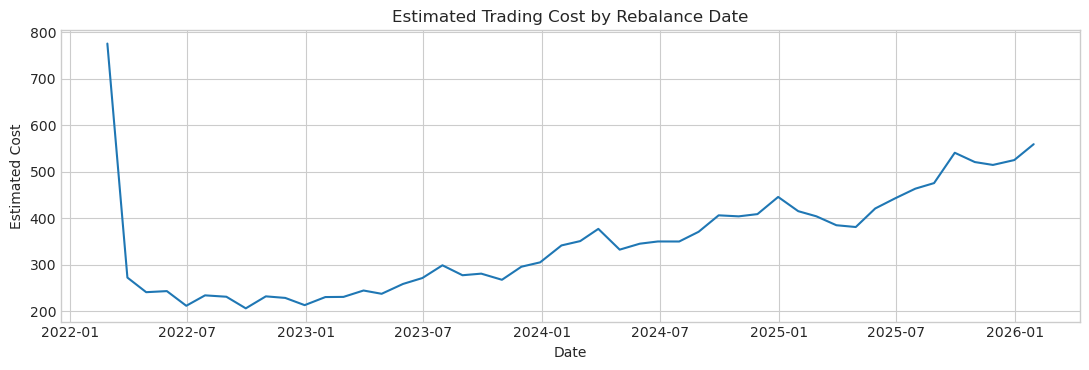

In [24]:
if orders_history is not None and len(orders_history) > 0 and 'trade_date' in orders_history.columns:
    o = orders_history.copy()
    o['notional'] = pd.to_numeric(o.get('notional', 0.0), errors='coerce').fillna(0.0)
    o['estimated_cost'] = pd.to_numeric(o.get('estimated_cost', 0.0), errors='coerce').fillna(0.0)
    daily_orders = o.groupby('trade_date', as_index=False).agg(
        orders_count=('symbol', 'size'),
        gross_notional=('notional', lambda x: float(x.abs().sum())),
        net_notional=('notional', 'sum'),
        estimated_cost=('estimated_cost', 'sum'),
    ).sort_values('trade_date')
    display(daily_orders.tail(20))

    largest_orders = o.assign(abs_notional=o['notional'].abs()).sort_values('abs_notional', ascending=False)
    display(largest_orders[['trade_date', 'symbol', 'action', 'delta_weight', 'notional', 'estimated_cost']].head(25))

    fig, ax = plt.subplots(figsize=(11, 3.8))
    ax.plot(daily_orders['trade_date'], daily_orders['estimated_cost'])
    ax.set_title('Estimated Trading Cost by Rebalance Date')
    ax.set_xlabel('Date')
    ax.set_ylabel('Estimated Cost')
    plt.tight_layout()
    plt.show()
else:
    print('orders_history.csv not found or missing trade_date column.')
